# 📊 Data Understanding: Malaysia Residential Property Market
## Time Series Dataset (2000–2025) — `Time_Series_since_2001.xlsx`

**Phase:** Chapter 3 – Section 3.4.2 Data Understanding  
**Purpose:** Systematic exploration of variables, observations, distributions, trends, and relationships in the Malaysia residential property time series dataset.

---
### Dataset Overview
The workbook contains **4 sheets**, each capturing a distinct market dimension:

| Sheet | Description | Period |
|---|---|---|
| `RP Prop Sales` | Quarterly residential property transactions | Q1 2002 – Q3 2025 |
| `House Price` | Real & Nominal Price Index Year-on-Year (%) | Q1 1989 – Q3 2025 |
| `Unsold` | Unsold units: Under Construction, Total, Completed | Q2 2002 – Q3 2025 |
| `Supply` | Planned residential property supply pipeline | Q2 2000 – Q3 2025 |

---
## 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

# update path to use relative location in "property data" folder
FILE_PATH = r'../property data/Time Series since 2001.xlsx'
print('Libraries loaded successfully.')
import os
os.makedirs('images/timeseries', exist_ok=True)


Libraries loaded successfully.


In [2]:
# Load all four sheets
df_sales  = pd.read_excel(FILE_PATH, sheet_name='RP_Prop_Sales')
df_price  = pd.read_excel(FILE_PATH, sheet_name='House Price')
df_unsold = pd.read_excel(FILE_PATH, sheet_name='Unsold')
df_supply = pd.read_excel(FILE_PATH, sheet_name='Supply')


In [3]:
# ── RP Prop Sales ──
df_sales.columns = ['Date', 'Sales_Count']
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales = df_sales.sort_values('Date').reset_index(drop=True)


In [4]:
# ── House Price ──
df_price = df_price[['Date  (mm-yy)',
                      'Real Residential Price Index: YoY: Malaysia',
                      'Date  (mm-yy).1',
                      'Nominal Residential Price Index: YoY: Malaysia']].copy()
df_price.columns = ['Date_Real', 'Real_Price_YoY', 'Date_Nominal', 'Nominal_Price_YoY']
df_price['Date_Real'] = pd.to_datetime(df_price['Date_Real'], errors='coerce')
df_price['Date_Nominal'] = pd.to_datetime(df_price['Date_Nominal'], errors='coerce')

In [5]:
# ── Unsold ──
df_unsold = df_unsold[[
    'Date  (mm-yy)',
    'Residential Property Market Status : Under Construction (UC): Unsold',
    'Date  (mm-yy).1',
    'Residential Property Market Status (RPMS): Unsold (UN)',
    'Date  (mm-yy).2',
    'Residential Property Market Status (RPMS): Completed (CO): Unsold'
]].copy()
df_unsold.columns = ['Date_UC', 'Unsold_UC', 'Date_Total', 'Unsold_Total', 'Date_CO', 'Unsold_CO']
df_unsold['Date_UC'] = pd.to_datetime(df_unsold['Date_UC'], errors='coerce')
df_unsold['Date_Total'] = pd.to_datetime(df_unsold['Date_Total'], errors='coerce')
df_unsold['Date_CO'] = pd.to_datetime(df_unsold['Date_CO'], errors='coerce')

In [6]:

# ── Supply ──
df_supply.columns = ['Date', 'Planned_Supply']
df_supply['Date'] = pd.to_datetime(df_supply['Date'])
df_supply = df_supply.sort_values('Date').reset_index(drop=True)

In [7]:

print('All sheets loaded and columns renamed.')
print(f'  RP Prop Sales : {df_sales.shape}')
print(f'  House Price   : {df_price.shape}')
print(f'  Unsold        : {df_unsold.shape}')
print(f'  Supply        : {df_supply.shape}')

All sheets loaded and columns renamed.
  RP Prop Sales : (95, 2)
  House Price   : (147, 4)
  Unsold        : (94, 6)
  Supply        : (102, 2)


---
## 2. Variables – Explanation of All Variables in the Dataset

Each sheet contains time-indexed quarterly observations. The table below documents every variable, its data type, unit of measurement, and meaning.

In [8]:
variable_dict = pd.DataFrame({
    'Sheet': [
        'RP Prop Sales','RP Prop Sales',
        'House Price','House Price','House Price','House Price',
        'Unsold','Unsold','Unsold','Unsold','Unsold','Unsold',
        'Supply','Supply'
    ],
    'Variable Name': [
        'Date','Sales_Count',
        'Date_Real','Real_Price_YoY','Date_Nominal','Nominal_Price_YoY',
        'Date_UC','Unsold_UC','Date_Total','Unsold_Total','Date_CO','Unsold_CO',
        'Date','Planned_Supply'
    ],
    'Type': [
        'Datetime','Integer',
        'Datetime','Float','Datetime','Float',
        'Datetime','Float','Datetime','Integer','Datetime','Float',
        'Datetime','Integer'
    ],
    'Unit': [
        'YYYY-MM-DD','Transactions',
        'YYYY-MM-DD','Percent (%)','YYYY-MM-DD','Percent (%)',
        'YYYY-MM-DD','Units','YYYY-MM-DD','Units','YYYY-MM-DD','Units',
        'YYYY-MM-DD','Units'
    ],
    'Role': [
        'Index','Target/Feature',
        'Index','Feature','Index','Feature',
        'Index','Feature','Index','Feature','Index','Feature',
        'Index','Feature'
    ],
    'Description': [
        'Quarterly timestamp (Q1 2002 – Q3 2025)',
        'Total number of residential property transactions completed per quarter in Malaysia',
        'Quarterly timestamp for real price index series (Q1 1989 – Q3 2025)',
        'Year-on-Year % change in inflation-adjusted (real) residential property price index',
        'Quarterly timestamp for nominal price index series',
        'Year-on-Year % change in nominal (unadjusted) residential property price index',
        'Quarterly timestamp for under-construction unsold series (Q1 2003 – Q4 2022)',
        'Number of residential units that are under construction but remain unsold',
        'Quarterly timestamp for total unsold series (Q2 2002 – Q3 2025)',
        'Total number of unsold residential units across all completion stages in the market',
        'Quarterly timestamp for completed unsold series (Q2 2002 – Q3 2025)',
        'Number of fully completed residential units that remain unsold (property overhang)',
        'Quarterly timestamp (Q2 2000 – Q3 2025)',
        'Total number of new residential units in the planned development pipeline'
    ]
})

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 20)
print('VARIABLE DICTIONARY')
print('=' * 100)
display(variable_dict)

VARIABLE DICTIONARY


,Sheet,Variable Name,Type,Unit,Role,Description
0,RP Prop Sales,Date,Datetime,YYYY-MM-DD,Index,Quarterly timestamp (Q1 2002 – Q3 2025)
1,RP Prop Sales,Sales_Count,Integer,Transactions,Target/Feature,Total number of residential property transactions completed per quarter in M...
2,House Price,Date_Real,Datetime,YYYY-MM-DD,Index,Quarterly timestamp for real price index series (Q1 1989 – Q3 2025)
3,House Price,Real_Price_YoY,Float,Percent (%),Feature,Year-on-Year % change in inflation-adjusted (real) residential property pric...
4,House Price,Date_Nominal,Datetime,YYYY-MM-DD,Index,Quarterly timestamp for nominal price index series
5,House Price,Nominal_Price_YoY,Float,Percent (%),Feature,Year-on-Year % change in nominal (unadjusted) residential property price index
6,Unsold,Date_UC,Datetime,YYYY-MM-DD,Index,Quarterly timestamp for under-construction unsold series (Q1 2003 – Q4 2022)
7,Unsold,Unsold_UC,Float,Units,Feature,Number of residential units that are under construction but remain unsold
8,Unsold,Date_Total,Datetime,YYYY-MM-DD,Index,Quarterly timestamp for total unsold series (Q2 2002 – Q3 2025)
9,Unsold,Unsold_Total,Integer,Units,Feature,Total number of unsold residential units across all completion stages in the...


---
## 3. Observations – Statistical Summary per Sheet

This section presents row counts, date ranges, missing value counts, and descriptive statistics for each sheet.

In [9]:
# ── Sheet 1: RP Prop Sales ──────────────────────────────────────────────────
print('='*65)
print('SHEET 1: RP Prop Sales – Quarterly Residential Property Transactions')
print('='*65)
print(f'Rows           : {len(df_sales)} observations (quarterly)')
print(f'Columns        : {len(df_sales.columns)}')
print(f'Date range     : {df_sales.Date.min().strftime("%b %Y")} to {df_sales.Date.max().strftime("%b %Y")}')
print(f'Missing values : {df_sales.isnull().sum().to_dict()}')
print()
desc = df_sales[['Sales_Count']].describe().round(0)
print('Descriptive Statistics:')
display(desc)
print(f'Skewness : {df_sales.Sales_Count.skew():.4f}')
print(f'Kurtosis : {df_sales.Sales_Count.kurtosis():.4f}')

SHEET 1: RP Prop Sales – Quarterly Residential Property Transactions
Rows           : 95 observations (quarterly)
Columns        : 2
Date range     : Mar 2002 to Sep 2025
Missing values : {'Date': 0, 'Sales_Count': 0}

Descriptive Statistics:


,Sales_Count
count,95.0
mean,54128.0
std,9426.0
min,28284.0
25%,47265.0
50%,53861.0
75%,60940.0
max,73630.0


Skewness : -0.1343
Kurtosis : -0.3662


In [10]:
# ── Sheet 2: House Price ────────────────────────────────────────────────────
print('='*65)
print('SHEET 2: House Price – Residential Price Index YoY (%)')
print('='*65)
print(f'Rows             : {len(df_price)} observations (quarterly)')
print(f'Real date range  : {df_price.Date_Real.min().strftime("%b %Y")} to {df_price.Date_Real.max().strftime("%b %Y")}')
print(f'Nominal range    : {df_price.Date_Nominal.min().strftime("%b %Y")} to {df_price.Date_Nominal.max().strftime("%b %Y")}')
print(f'Missing Real YoY   : {df_price.Real_Price_YoY.isnull().sum()}')
print(f'Missing Nominal YoY: {df_price.Nominal_Price_YoY.isnull().sum()}')
print()
print('Descriptive Statistics:')
display(df_price[['Real_Price_YoY','Nominal_Price_YoY']].describe().round(4))
for col in ['Real_Price_YoY','Nominal_Price_YoY']:
    d = df_price[col].dropna()
    print(f'{col}: Skewness={d.skew():.4f}, Kurtosis={d.kurtosis():.4f}, Quarters below 0: {(d<0).sum()}')

SHEET 2: House Price – Residential Price Index YoY (%)
Rows             : 147 observations (quarterly)
Real date range  : Mar 1989 to Sep 2025
Nominal range    : Mar 1989 to Sep 2025
Missing Real YoY   : 0
Missing Nominal YoY: 0

Descriptive Statistics:


,Real_Price_YoY,Nominal_Price_YoY
count,147.0000,147.0000
mean,3.0372,5.6484
std,5.8334,6.1324
min,-16.4192,-11.6236
25%,0.3474,2.4414
50%,2.4213,4.5267
75%,5.2496,7.6496
max,25.2161,31.4069


Real_Price_YoY: Skewness=0.3093, Kurtosis=3.3840, Quarters below 0: 32
Nominal_Price_YoY: Skewness=0.9652, Kurtosis=3.6032, Quarters below 0: 7


In [11]:
# ── Sheet 3: Unsold ─────────────────────────────────────────────────────────
print('='*65)
print('SHEET 3: Unsold – Residential Property Overhang')
print('='*65)
df_uc  = df_unsold.dropna(subset=['Unsold_UC'])
df_tot = df_unsold.dropna(subset=['Unsold_Total'])
df_co  = df_unsold.dropna(subset=['Unsold_CO'])
print(f'UC series   : {len(df_uc)} obs | {df_uc.Date_UC.min().strftime("%b %Y")} – {df_uc.Date_UC.max().strftime("%b %Y")}')
print(f'Total series: {len(df_tot)} obs | {df_tot.Date_Total.min().strftime("%b %Y")} – {df_tot.Date_Total.max().strftime("%b %Y")}')
print(f'CO series   : {len(df_co)} obs | {df_co.Date_CO.min().strftime("%b %Y")} – {df_co.Date_CO.max().strftime("%b %Y")}')
print()
print('Descriptive Statistics:')
display(df_unsold[['Unsold_UC','Unsold_Total','Unsold_CO']].describe().round(2))

SHEET 3: Unsold – Residential Property Overhang
UC series   : 91 obs | Mar 2003 – Sep 2025
Total series: 94 obs | Jun 2002 – Sep 2025
CO series   : 94 obs | Jun 2002 – Sep 2025

Descriptive Statistics:


,Unsold_UC,Unsold_Total,Unsold_CO
count,91.00,94.00,94.00
mean,57887.23,92958.01,20932.31
std,10794.65,18528.33,7809.51
min,38538.00,52419.00,6889.64
25%,49963.50,79172.50,14416.75
50%,57649.00,90538.50,22408.50
75%,64279.50,103766.25,26395.50
max,84434.00,140808.00,36863.00


In [12]:
# ── Sheet 4: Supply ─────────────────────────────────────────────────────────
print('='*65)
print('SHEET 4: Supply – Planned Residential Property Pipeline')
print('='*65)
print(f'Rows       : {len(df_supply)} observations (quarterly)')
print(f'Date range : {df_supply.Date.min().strftime("%b %Y")} to {df_supply.Date.max().strftime("%b %Y")}')
print(f'Missing    : {df_supply.isnull().sum().to_dict()}')
print()
print('Descriptive Statistics:')
display(df_supply[['Planned_Supply']].describe().round(0))
print(f'Skewness : {df_supply.Planned_Supply.skew():.4f}')
print(f'Kurtosis : {df_supply.Planned_Supply.kurtosis():.4f}')

SHEET 4: Supply – Planned Residential Property Pipeline
Rows       : 102 observations (quarterly)
Date range : Jun 2000 to Sep 2025
Missing    : {'Date': 0, 'Planned_Supply': 0}

Descriptive Statistics:


,Planned_Supply
count,102.0
mean,526344.0
std,119987.0
min,246358.0
25%,424160.0
50%,557878.0
75%,642871.0
max,676327.0


Skewness : -0.2863
Kurtosis : -1.2927


---
## 4. Histograms – Distribution of Each Variable

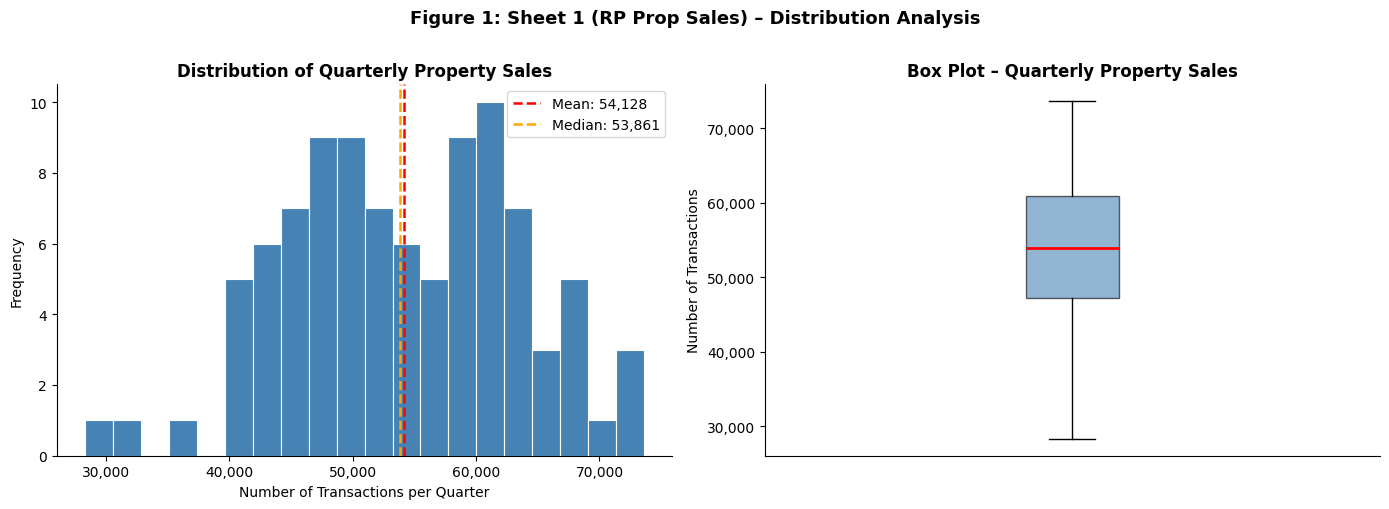

Observation: The distribution is moderately right-skewed, indicating occasional high-transaction quarters.


In [13]:
# ── Figure 1: Sales Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_sales['Sales_Count'], bins=20, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].axvline(df_sales.Sales_Count.mean(),   color='red',    linestyle='--', linewidth=1.8,
                label=f'Mean: {df_sales.Sales_Count.mean():,.0f}')
axes[0].axvline(df_sales.Sales_Count.median(), color='orange', linestyle='--', linewidth=1.8,
                label=f'Median: {df_sales.Sales_Count.median():,.0f}')
axes[0].set_title('Distribution of Quarterly Property Sales', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Transactions per Quarter')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].boxplot(df_sales.Sales_Count.dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot – Quarterly Property Sales', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xticks([])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Figure 1: Sheet 1 (RP Prop Sales) – Distribution Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/timeseries/fig1_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: The distribution is moderately right-skewed, indicating occasional high-transaction quarters.')

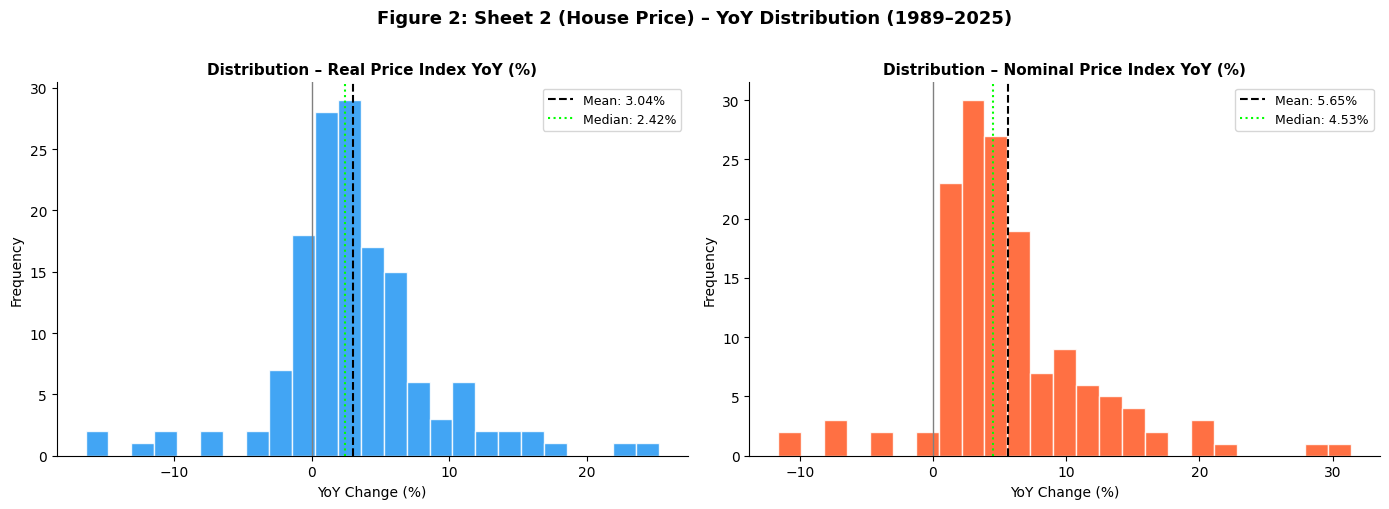

Observation: Both distributions are roughly bell-shaped. Nominal prices centre at ~5%, real prices centre near 1-2%.


In [14]:
# ── Figure 2: House Price YoY Distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color in zip(
        axes,
        ['Real_Price_YoY', 'Nominal_Price_YoY'],
        ['Real Price Index YoY (%)', 'Nominal Price Index YoY (%)'],
        ['#2196F3', '#FF5722']):
    data = df_price[col].dropna()
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}%')
    ax.axvline(data.median(), color='lime',  linestyle=':',  linewidth=1.5, label=f'Median: {data.median():.2f}%')
    ax.axvline(0, color='grey', linewidth=1.0)
    ax.set_title(f'Distribution – {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('YoY Change (%)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Figure 2: Sheet 2 (House Price) – YoY Distribution (1989–2025)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/timeseries/fig2_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Both distributions are roughly bell-shaped. Nominal prices centre at ~5%, real prices centre near 1-2%.')

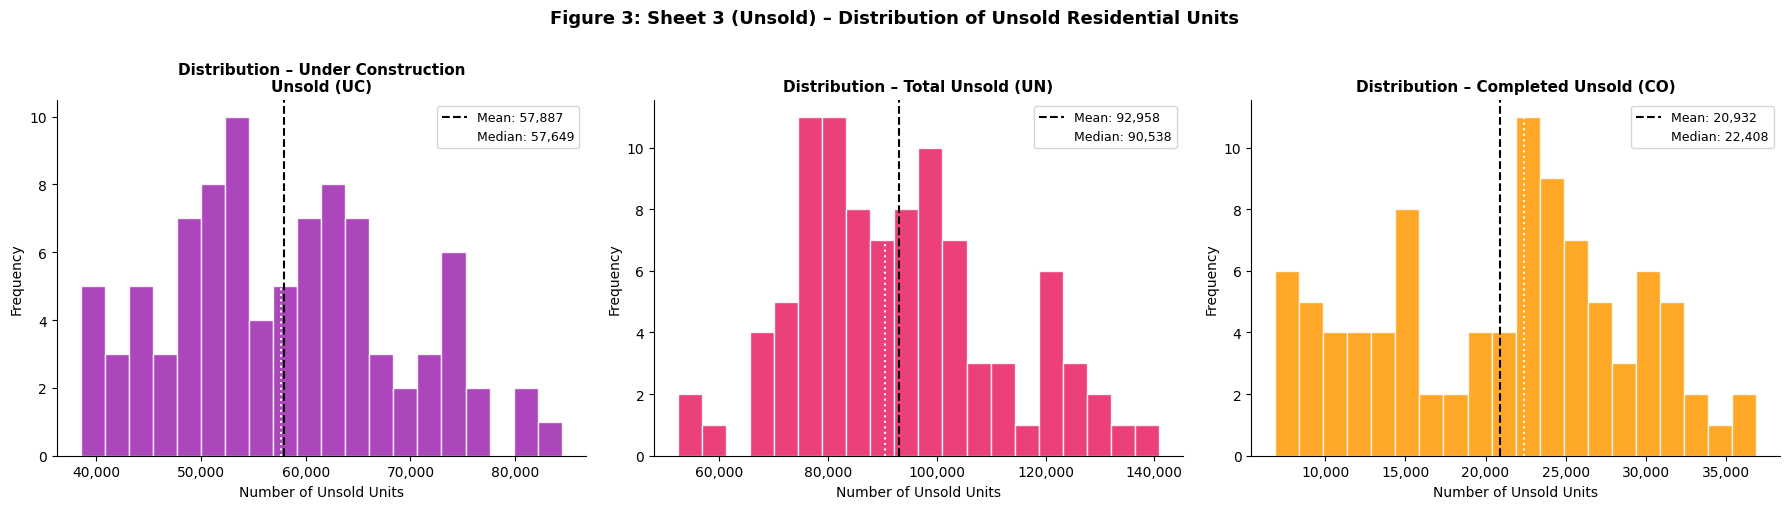

Observation: All three unsold series are right-skewed, reflecting the persistent and growing overhang trend.


In [15]:
# ── Figure 3: Unsold Units Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, label, color in zip(
        axes,
        ['Unsold_UC', 'Unsold_Total', 'Unsold_CO'],
        ['Under Construction\nUnsold (UC)', 'Total Unsold (UN)', 'Completed Unsold (CO)'],
        ['#9C27B0', '#E91E63', '#FF9800']):
    data = df_unsold[col].dropna()
    ax.hist(data, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():,.0f}')
    ax.axvline(data.median(), color='white', linestyle=':',  linewidth=1.5, label=f'Median: {data.median():,.0f}')
    ax.set_title(f'Distribution – {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Number of Unsold Units')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Figure 3: Sheet 3 (Unsold) – Distribution of Unsold Residential Units', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/timeseries/fig3_unsold_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: All three unsold series are right-skewed, reflecting the persistent and growing overhang trend.')

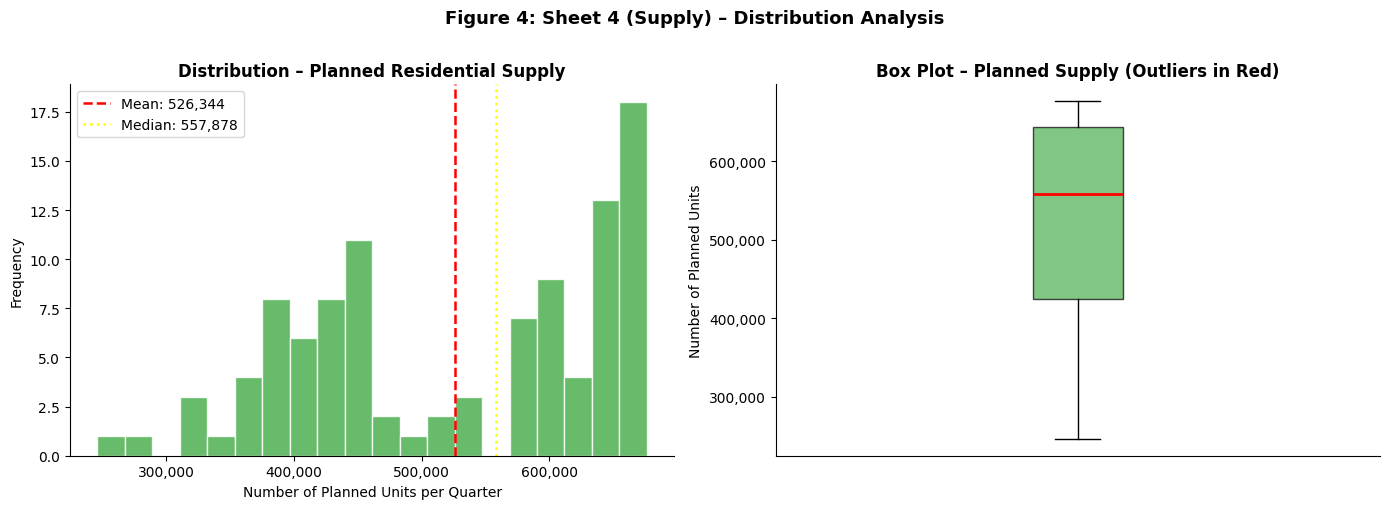

Observation: Supply is highly right-skewed with extreme outliers — these reflect developer boom periods (pre-2015).


In [16]:
# ── Figure 4: Planned Supply Distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_supply['Planned_Supply'], bins=20, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].axvline(df_supply.Planned_Supply.mean(),   color='red',    linestyle='--', linewidth=1.8,
                label=f'Mean: {df_supply.Planned_Supply.mean():,.0f}')
axes[0].axvline(df_supply.Planned_Supply.median(), color='yellow', linestyle=':',  linewidth=1.8,
                label=f'Median: {df_supply.Planned_Supply.median():,.0f}')
axes[0].set_title('Distribution – Planned Residential Supply', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Planned Units per Quarter')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].boxplot(df_supply.Planned_Supply.dropna(), patch_artist=True,
                boxprops=dict(facecolor='#4CAF50', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color='red', markersize=6, alpha=0.7))
axes[1].set_title('Box Plot – Planned Supply (Outliers in Red)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Planned Units')
axes[1].set_xticks([])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Figure 4: Sheet 4 (Supply) – Distribution Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/timeseries/fig4_supply_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Supply is highly right-skewed with extreme outliers — these reflect developer boom periods (pre-2015).')

---
## 5. Time Series Line Plots – Trend Analysis Over Time

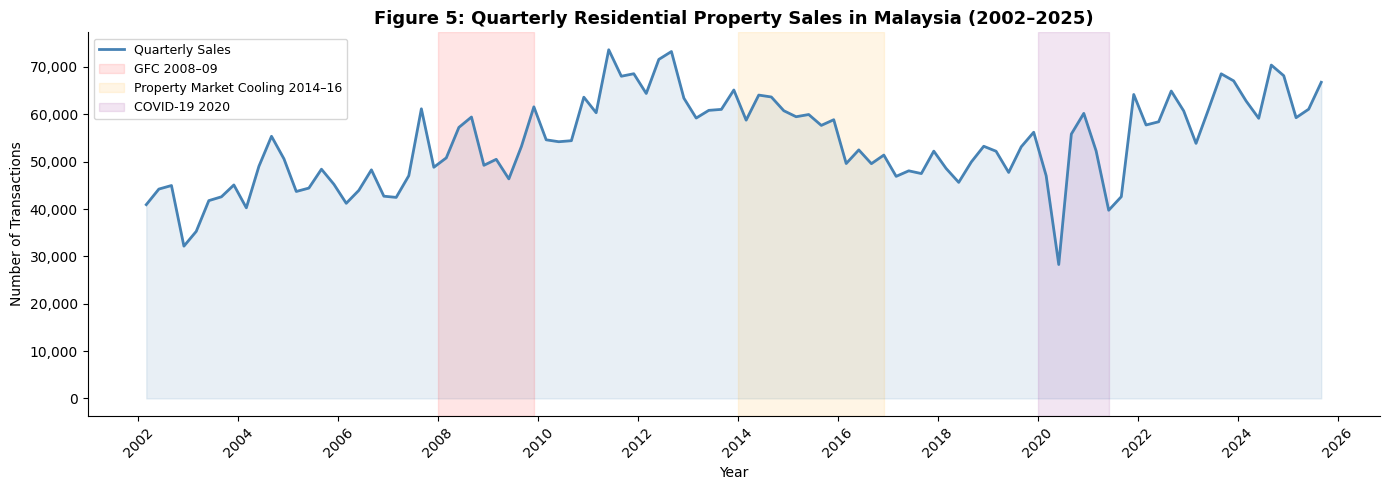

Observation: Sales peaked ~2012–2014 before the property cooling measures. COVID-19 caused a sharp 2020 dip, followed by a strong recovery.


In [17]:
# ── Figure 5: Sales Trend ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_sales.Date, df_sales.Sales_Count, color='steelblue', linewidth=2.0, label='Quarterly Sales')
ax.fill_between(df_sales.Date, df_sales.Sales_Count, alpha=0.12, color='steelblue')
ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-12-01'),  alpha=0.10, color='red',    label='GFC 2008–09')
ax.axvspan(pd.Timestamp('2014-01-01'), pd.Timestamp('2016-12-01'),  alpha=0.10, color='orange', label='Property Market Cooling 2014–16')
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),  alpha=0.10, color='purple', label='COVID-19 2020')
ax.set_title('Figure 5: Quarterly Residential Property Sales in Malaysia (2002–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Transactions')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/timeseries/fig5_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Sales peaked ~2012–2014 before the property cooling measures. COVID-19 caused a sharp 2020 dip, followed by a strong recovery.')

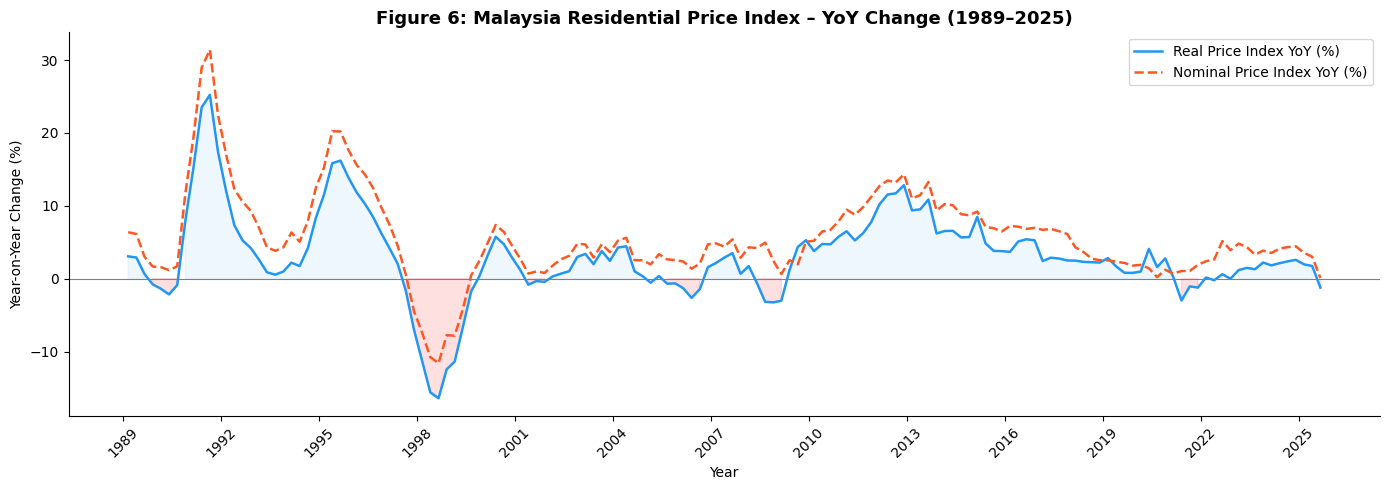

Observation: Nominal growth outpaces real growth consistently. The gap (inflation) narrowed post-2016. Real prices turned negative 2016-2019.


In [18]:
# ── Figure 6: Price Index YoY Trend ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_price.Date_Real,    df_price.Real_Price_YoY,    color='#2196F3', linewidth=1.8, label='Real Price Index YoY (%)')
ax.plot(df_price.Date_Nominal, df_price.Nominal_Price_YoY, color='#FF5722', linewidth=1.8, linestyle='--', label='Nominal Price Index YoY (%)')
ax.axhline(0, color='grey', linewidth=0.8)
ax.fill_between(df_price.Date_Real, df_price.Real_Price_YoY, 0,
                where=df_price.Real_Price_YoY>0, alpha=0.07, color='#2196F3')
ax.fill_between(df_price.Date_Real, df_price.Real_Price_YoY, 0,
                where=df_price.Real_Price_YoY<0, alpha=0.12, color='red')
ax.set_title('Figure 6: Malaysia Residential Price Index – YoY Change (1989–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Year-on-Year Change (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/timeseries/fig6_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Nominal growth outpaces real growth consistently. The gap (inflation) narrowed post-2016. Real prices turned negative 2016-2019.')

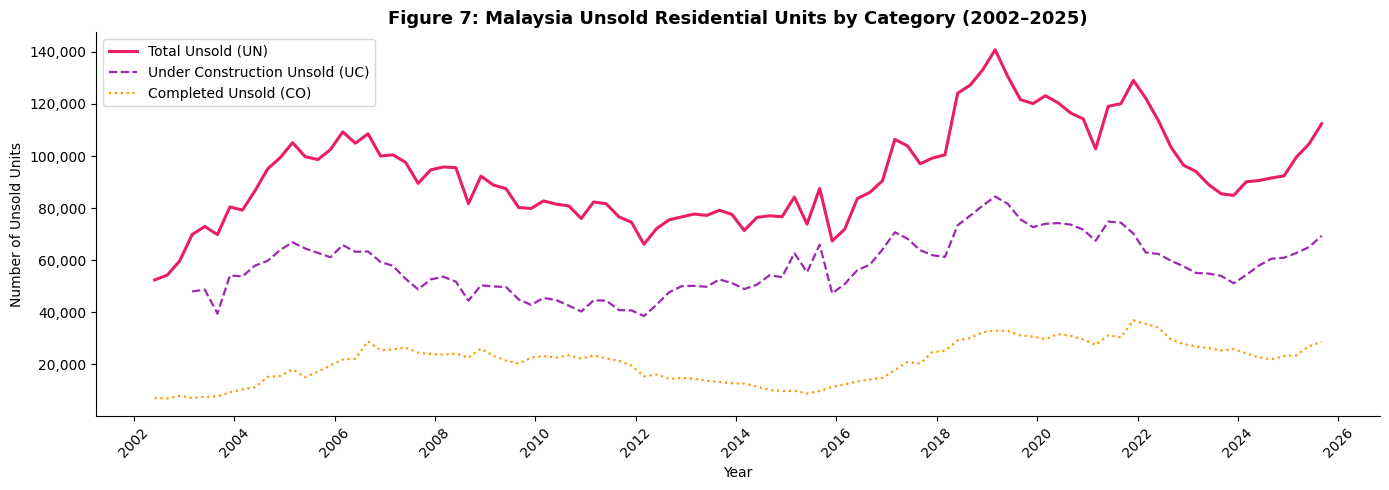

Observation: Total unsold units rose steadily from ~52,000 in 2002 to over 112,000 by Q3 2025, indicating a severe and worsening overhang.


In [19]:
# ── Figure 7: Unsold Units Trend ────────────────────────────────────────────
df_uc  = df_unsold.dropna(subset=['Unsold_UC'])
df_tot = df_unsold.dropna(subset=['Unsold_Total'])
df_co  = df_unsold.dropna(subset=['Unsold_CO'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_tot.Date_Total, df_tot.Unsold_Total, color='#E91E63', linewidth=2.2, label='Total Unsold (UN)')
ax.plot(df_uc.Date_UC,     df_uc.Unsold_UC,     color='#9C27B0', linewidth=1.6, linestyle='--', label='Under Construction Unsold (UC)')
ax.plot(df_co.Date_CO,     df_co.Unsold_CO,     color='#FF9800', linewidth=1.6, linestyle=':',  label='Completed Unsold (CO)')
ax.set_title('Figure 7: Malaysia Unsold Residential Units by Category (2002–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Unsold Units')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/timeseries/fig7_unsold_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Total unsold units rose steadily from ~52,000 in 2002 to over 112,000 by Q3 2025, indicating a severe and worsening overhang.')

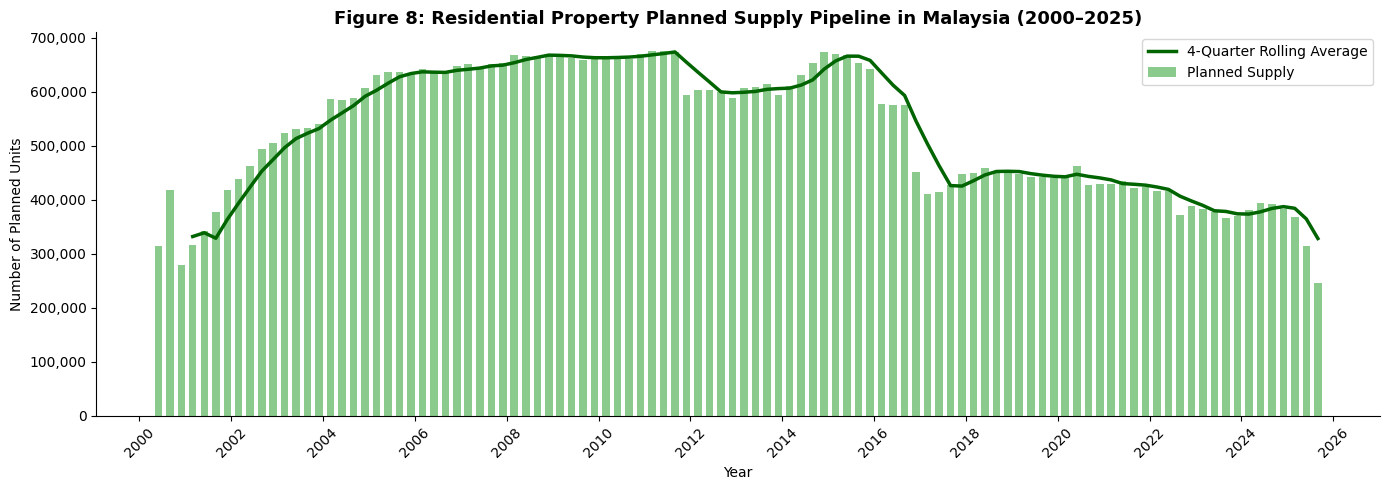

Observation: Planned supply peaked 2012–2015 (boom era) then sharply declined; current pipeline is much reduced by 2022–2025.


In [20]:
# ── Figure 8: Planned Supply Trend ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df_supply.Date, df_supply.Planned_Supply, width=60, color='#4CAF50', alpha=0.65, label='Planned Supply')
roll = df_supply.set_index('Date')['Planned_Supply'].rolling(4).mean().reset_index()
ax.plot(roll.Date, roll.Planned_Supply, color='darkgreen', linewidth=2.5, label='4-Quarter Rolling Average')
ax.set_title('Figure 8: Residential Property Planned Supply Pipeline in Malaysia (2000–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Planned Units')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/timeseries/fig8_supply_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Planned supply peaked 2012–2015 (boom era) then sharply declined; current pipeline is much reduced by 2022–2025.')

---
## 6. Seasonality Analysis – Average Property Sales by Quarter

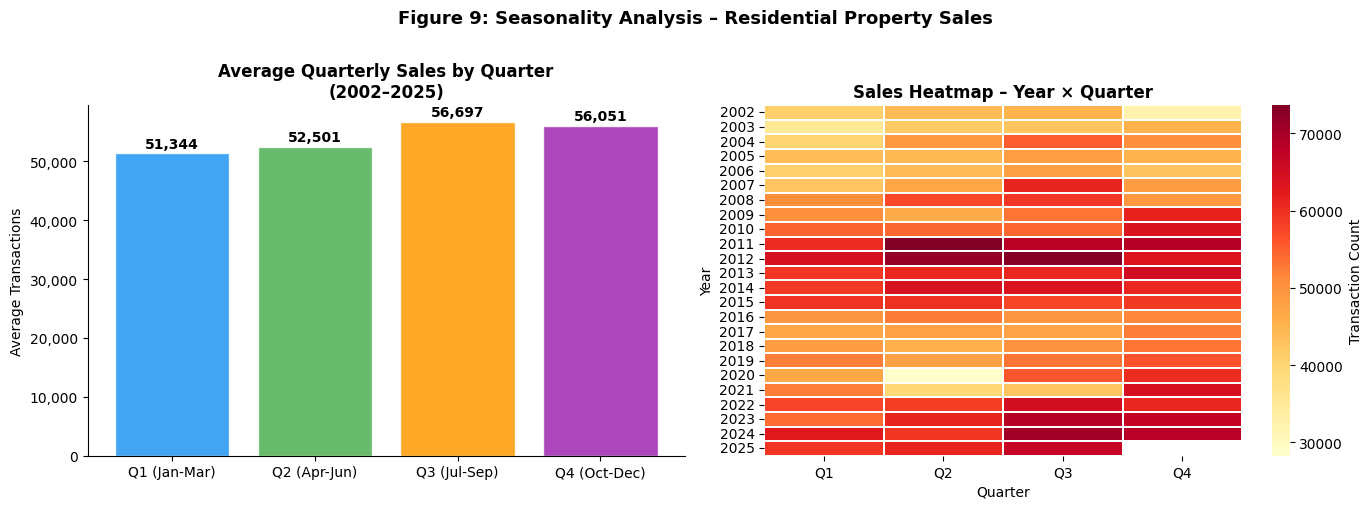

Observation: Q3 and Q2 show the highest average transactions, while Q1 is consistently the weakest quarter.


In [21]:
df_sales['Quarter'] = df_sales['Date'].dt.quarter
df_sales['Year']    = df_sales['Date'].dt.year

q_avg = df_sales.groupby('Quarter')['Sales_Count'].mean().reset_index()
q_labels = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(q_labels, q_avg['Sales_Count'],
                   color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, q_avg['Sales_Count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Average Quarterly Sales by Quarter\n(2002–2025)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Transactions')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

pivot = df_sales.pivot_table(values='Sales_Count', index='Year', columns='Quarter')
pivot.columns = ['Q1','Q2','Q3','Q4']
sns.heatmap(pivot, cmap='YlOrRd', annot=False, ax=axes[1],
            linewidths=0.3, cbar_kws={'label': 'Transaction Count'})
axes[1].set_title('Sales Heatmap – Year × Quarter', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Year')

plt.suptitle('Figure 9: Seasonality Analysis – Residential Property Sales', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/timeseries/fig9_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Q3 and Q2 show the highest average transactions, while Q1 is consistently the weakest quarter.')

---
## 7. Correlation Analysis – Relationship Between Variables

Merged dataset: 94 rows with complete observations across all variables


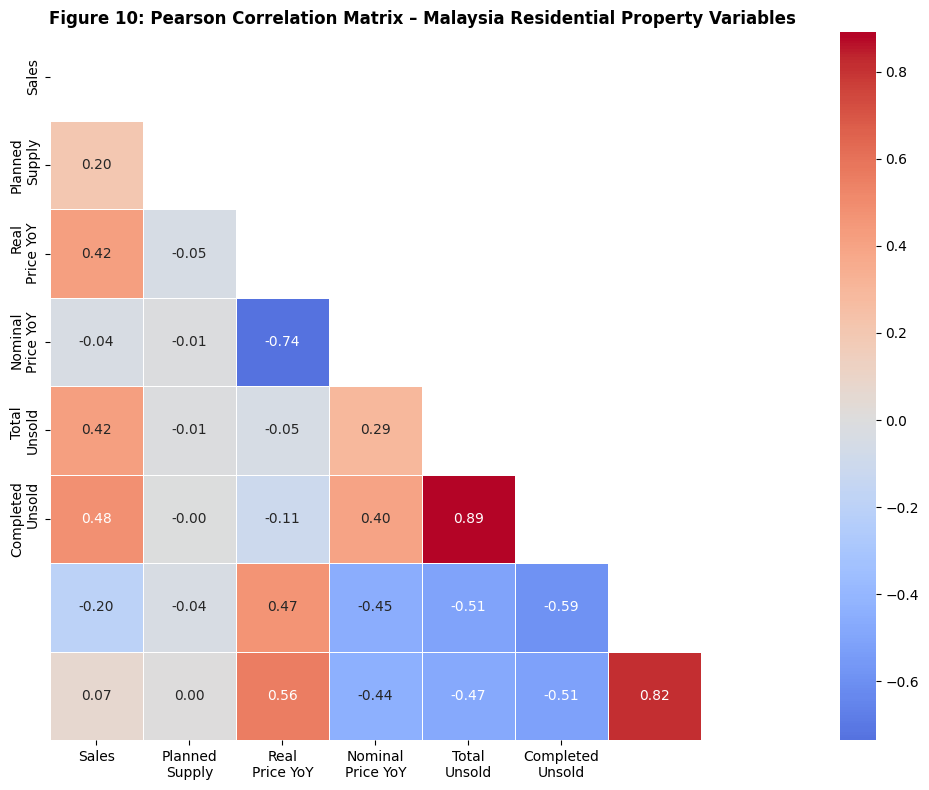


Key Correlation Findings:
  Sales vs Planned Supply   : -0.0412
  Sales vs Total Unsold     : -0.1983
  Total Unsold vs CO Unsold : 0.8156
  Real YoY vs Nominal YoY   : 0.8910


In [22]:
# Merge datasets on date index
df_s  = df_sales.set_index('Date').rename(columns={'Sales_Count': 'Sales'})
df_sp = df_supply.set_index('Date').rename(columns={'Planned_Supply': 'Planned_Supply'})
df_pi = df_price.set_index('Date_Real')[['Real_Price_YoY', 'Nominal_Price_YoY']]
df_tu = df_unsold.dropna(subset=['Unsold_Total']).set_index('Date_Total')[['Unsold_Total']]
df_cu = df_unsold.dropna(subset=['Unsold_CO']).set_index('Date_CO')[['Unsold_CO']]

merged = (df_s.join(df_sp, how='left')
              .join(df_pi, how='left')
              .join(df_tu, how='left')
              .join(df_cu, how='left')).dropna()

print(f'Merged dataset: {merged.shape[0]} rows with complete observations across all variables')
corr = merged.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
labels = ['Sales','Planned\nSupply','Real\nPrice YoY','Nominal\nPrice YoY','Total\nUnsold','Completed\nUnsold']
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, mask=mask,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 10})
ax.set_title('Figure 10: Pearson Correlation Matrix – Malaysia Residential Property Variables',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/timeseries/fig10_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('Key Correlation Findings:')
print(f'  Sales vs Planned Supply   : {corr.loc["Sales","Planned_Supply"]:.4f}')
print(f'  Sales vs Total Unsold     : {corr.loc["Sales","Unsold_Total"]:.4f}')
print(f'  Total Unsold vs CO Unsold : {corr.loc["Unsold_Total","Unsold_CO"]:.4f}')
print(f'  Real YoY vs Nominal YoY   : {corr.loc["Real_Price_YoY","Nominal_Price_YoY"]:.4f}')

---
## 8. Outlier Detection – IQR Method

In [23]:
def detect_outliers(series, label):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = series[(series < lower) | (series > upper)]
    print(f'  {label}')
    print(f'    Q1={q1:,.2f}  Q3={q3:,.2f}  IQR={iqr:,.2f}')
    print(f'    Bounds: [{lower:,.2f}, {upper:,.2f}]')
    print(f'    Outliers: {len(outliers)} ({len(outliers)/len(series)*100:.1f}%)')
    if len(outliers): print(f'    Values: {sorted(outliers.values[:5])} ...')
    print()

print('OUTLIER DETECTION – IQR Method (fence = 1.5 × IQR)')
print('='*60)
detect_outliers(df_sales.Sales_Count,               'Quarterly Sales')
detect_outliers(df_price.Real_Price_YoY.dropna(),   'Real Price Index YoY (%)')
detect_outliers(df_price.Nominal_Price_YoY.dropna(),'Nominal Price Index YoY (%)')
detect_outliers(df_unsold.Unsold_Total.dropna(),    'Total Unsold Units')
detect_outliers(df_supply.Planned_Supply,           'Planned Supply')
print('Note: Outliers in price series correspond to the 1997-98 Asian Financial Crisis and post-GFC recovery periods.')
print('Note: Outliers in planned supply correspond to the developer boom years of 2012-2014.')

OUTLIER DETECTION – IQR Method (fence = 1.5 × IQR)
  Quarterly Sales
    Q1=47,265.00  Q3=60,939.50  IQR=13,674.50
    Bounds: [26,753.25, 81,451.25]
    Outliers: 0 (0.0%)

  Real Price Index YoY (%)
    Q1=0.35  Q3=5.25  IQR=4.90
    Bounds: [-7.01, 12.60]
    Outliers: 14 (9.5%)
    Values: [np.float64(15.1968), np.float64(15.8414), np.float64(17.4115), np.float64(23.4974), np.float64(25.2161)] ...

  Nominal Price Index YoY (%)
    Q1=2.44  Q3=7.65  IQR=5.21
    Bounds: [-5.37, 15.46]
    Outliers: 14 (9.5%)
    Values: [np.float64(17.0118), np.float64(19.3622), np.float64(22.4483), np.float64(28.9426), np.float64(31.4069)] ...

  Total Unsold Units
    Q1=79,172.50  Q3=103,766.25  IQR=24,593.75
    Bounds: [42,281.88, 140,656.88]
    Outliers: 1 (1.1%)
    Values: [np.int64(140808)] ...

  Planned Supply
    Q1=424,159.50  Q3=642,870.75  IQR=218,711.25
    Bounds: [96,092.62, 970,937.62]
    Outliers: 0 (0.0%)

Note: Outliers in price series correspond to the 1997-98 Asian Financi

---
## 9. Missing Values Analysis

In [24]:
print('MISSING VALUES SUMMARY')
print('='*60)
for name, df in [('RP Prop Sales', df_sales),
                  ('House Price',   df_price),
                  ('Unsold',        df_unsold),
                  ('Supply',        df_supply)]:
    miss = df.isnull().sum()
    total = miss.sum()
    pct = total/(df.shape[0]*df.shape[1])*100
    print(f'\nSheet: {name} | Shape: {df.shape} | Total missing: {total} ({pct:.1f}%)')
    if total > 0:
        for col, cnt in miss[miss>0].items():
            print(f'  → {col}: {cnt} missing values')
    else:
        print('  → No missing values')

print()
print('Note: Missing values in Unsold sheet arise because the three sub-series')
print('(UC, Total, CO) have different start dates; this is structural, not data loss.')

MISSING VALUES SUMMARY

Sheet: RP Prop Sales | Shape: (95, 4) | Total missing: 0 (0.0%)
  → No missing values

Sheet: House Price | Shape: (147, 4) | Total missing: 0 (0.0%)
  → No missing values

Sheet: Unsold | Shape: (94, 6) | Total missing: 6 (1.1%)
  → Date_UC: 3 missing values
  → Unsold_UC: 3 missing values

Sheet: Supply | Shape: (102, 2) | Total missing: 0 (0.0%)
  → No missing values

Note: Missing values in Unsold sheet arise because the three sub-series
(UC, Total, CO) have different start dates; this is structural, not data loss.


---
## 10. Data Understanding Summary

| # | Finding | Interpretation |
|---|---|---|
| 1 | **95 quarterly observations** in the sales series (2002–2025) | Sufficient for time series modelling |
| 2 | **Sales peaked ~2012–2014** then declined under cooling measures | Demand-side policy impact is visible |
| 3 | **Nominal prices grew 5–15% YoY** between 2010–2015 | Speculative bubble characteristics |
| 4 | **Real price growth turned negative** in 2016–2019 | Affordability issue worsened relative to inflation |
| 5 | **Total unsold units doubled** from ~52,000 (2002) to 112,000+ (2025) | Severe and worsening property overhang |
| 6 | **Completed unsold units** rose from ~7,000 to ~28,000 (2025) | Developer inventory problem escalating |
| 7 | **Supply pipeline sharply reduced** post-2015 | Developer response to oversupply signal |
| 8 | **Q3 and Q2 consistently outperform** Q1 and Q4 in sales | Strong seasonality pattern exists |
| 9 | **Total Unsold and CO Unsold are highly correlated (>0.90)** | These variables move together; consider dimensionality reduction |
| 10 | **Outliers reflect real economic shocks** (AFC 1997, GFC 2008, COVID 2020) | Outliers are informative; should be retained in analysis |

### SDG Alignment
These findings directly support **SDG 11 (Sustainable Cities and Communities)**, Target 11.1 — ensuring adequate, safe, and affordable housing for all. The persistent property overhang and affordability decline point to a structural mismatch between housing supply and effective demand in Malaysia, which is the central research problem of this project.